# Robert Bektas
# Intro to Data Science 
# Portfolio Update 2 Assignment 

# This project demonstrates how messy data can be tidied up using python and pandas. The dataset used contains medal winners from the 2008 Olympic Games, where sport and gender information are embedded in column names, making it difficult for the viewer to compartmentalise the different characteristics of the data such as gender, sport and type of medal. 

# Using the principles we have learned, the dataset has been cleaned and reshaped to allow for a more effection visualisation. 


# 1. Import and Inspect Data

# The dataset is first loaded using pandas. I use functions such as df.head() and df.shape to identify how the data is laid out.

# In this dataset, sport and gender are stored within the column names, this violates tidy data principles we studied in class. 

# The wide format makes it difficult to analyse data because multiple variables are combined into a single dimension.

In [56]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the Olympics medalists dataset
df = pd.read_csv("olympics_08_medalists.csv")

# Inspect the raw dataset
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

       medalist_name male_archery female_archery male_athletics  \
0    Aaron Armstrong          NaN            NaN           gold   
1      Aaron Peirsol          NaN            NaN            NaN   
2   Abdullo Tangriev          NaN            NaN            NaN   
3  Abeer Abdelrahman          NaN            NaN            NaN   
4            Abhinav          NaN            NaN            NaN   

  female_athletics male_badminton female_badminton male_baseball  \
0              NaN            NaN              NaN           NaN   
1              NaN            NaN              NaN           NaN   
2              NaN            NaN              NaN           NaN   
3              NaN            NaN              NaN           NaN   
4              NaN            NaN              NaN           NaN   

  male_basketball female_basketball  ... female_beach volleyball  \
0             NaN               NaN  ...                     NaN   
1             NaN               NaN  ...            

# 2. Reshaping the Dataset

# The dataset is transformed from wide format to a long format using "melt()" functions from pandas. 

# According to tidy data principles, each variable from should its own column and each observation should have its own row.

# By melting the dataset, sport and gender information are moved into a single column, which can then to separated into individual variables 

In [57]:
# Convert the dataset from wide format to long format
tidy_df = df.melt(
    id_vars="medalist_name",
    var_name="sport_gender",
    value_name="medal"
)

# Inspect the reshaped data
print(tidy_df.head())
print(tidy_df.shape)

       medalist_name  sport_gender medal
0    Aaron Armstrong  male_archery   NaN
1      Aaron Peirsol  male_archery   NaN
2   Abdullo Tangriev  male_archery   NaN
3  Abeer Abdelrahman  male_archery   NaN
4            Abhinav  male_archery   NaN
(131250, 3)


# 3. Removing Missing Observations 

# After reshaping, many rows contain missing values because each athele only competes in one event. 

# These rows are removed using "dropna()" to make sure that each row represents a valid medal observation.

# Cleaning missing data is important in preparing the datasets for analysis



In [58]:
# Remove rows where no medal was recorded
tidy_df.dropna(subset=["medal"], inplace=True)

# Inspect the cleaned long-format data
print(tidy_df.head())
print(tidy_df.shape)

      medalist_name  sport_gender   medal
177    Bair Badënov  male_archery  bronze
676   Ilario Di Buò  male_archery  silver
682    Im Dong-hyun  male_archery    gold
760       Jiang Lin  male_archery  bronze
920  Lee Chang-hwan  male_archery    gold
(1875, 3)


## 4.Splitting and Cleaning Variables

# The combined column containing sport and gender information is separated into two new variables using the pandas string method "str.split()".  

# Additional string cleaning is performed using methods such as "str.replace()" and "str.strip()" to ensure consistent formatting.  

# These steps follow guidance from the pandas cheat sheet, which highlights powerful tools for text manipulation in data cleaning workflows.

In [59]:
# Split the combined column into separate gender and sport columns
tidy_df[["gender", "sport"]] = tidy_df["sport_gender"].str.split("_", n=1, expand=True)

# Clean sport names for consistency
tidy_df["sport"] = tidy_df["sport"].str.replace("-", " ", regex=False).str.strip()

# Standardize medal text formatting
tidy_df["medal"] = tidy_df["medal"].str.lower().str.strip()

# Inspect the updated dataset
print(tidy_df.head())

      medalist_name  sport_gender   medal gender    sport
177    Bair Badënov  male_archery  bronze   male  archery
676   Ilario Di Buò  male_archery  silver   male  archery
682    Im Dong-hyun  male_archery    gold   male  archery
760       Jiang Lin  male_archery  bronze   male  archery
920  Lee Chang-hwan  male_archery    gold   male  archery


## 5. Verify the Final Tidy Dataset

The cleaned dataset now follows tidy data rules:

- Each variable has its own column (medalist name, gender, sport, medal).
- Each observation corresponds to one medal result.
- The dataset represents one clear observational unit.

Transforming data into tidy format improves readability and makes aggregation and visualization more straightforward.

In [60]:
# Drop the old combined column
tidy_df.drop(columns=["sport_gender"], inplace=True)

# Reorder columns for clarity
tidy_df = tidy_df[["medalist_name", "gender", "sport", "medal"]]

# Inspect the final tidy dataset
print(tidy_df.head())
print(tidy_df.info())

      medalist_name gender    sport   medal
177    Bair Badënov   male  archery  bronze
676   Ilario Di Buò   male  archery  silver
682    Im Dong-hyun   male  archery    gold
760       Jiang Lin   male  archery  bronze
920  Lee Chang-hwan   male  archery    gold
<class 'pandas.core.frame.DataFrame'>
Index: 1875 entries, 177 to 131234
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   medalist_name  1875 non-null   object
 1   gender         1875 non-null   object
 2   sport          1875 non-null   object
 3   medal          1875 non-null   object
dtypes: object(4)
memory usage: 73.2+ KB
None


## 6. Aggregation and Pivot Table Analysis

A pivot table is created to summarize medal counts by sport and medal type.  

Aggregation functions such as counting observations allow analysts to identify patterns and compare performance across different categories.

In [61]:
# Create a pivot table showing medal counts by sport and medal type
sport_medals = tidy_df.pivot_table(
    index="sport",
    columns="medal",
    aggfunc="size",
    fill_value=0
)

print(sport_medals.head(10))

medal                 bronze  gold  silver
sport                                     
archery                    8     5       7
artistic gymnastics       19    14      16
association football      36    37      36
athletics                 55    52      59
badminton                  7     7       8
baseball                  24    24      24
basketball                24    23      24
beach volleyball           4     4       4
bmx                        2     2       2
boxing                    22    11      11


In [62]:
# Group medal counts by gender and medal type
gender_medals = tidy_df.groupby(["gender", "medal"]).size().unstack(fill_value=0)

print(gender_medals)

medal   bronze  gold  silver
gender                      
female     294   271     278
male       374   315     343


## 7. Data Visualization

Visualizations are created to explore patterns in the tidy dataset.  

Bar charts help highlight:

- The sports with the highest number of medalists.
- Differences in medal distributions between male and female athletes.

Because the data is tidy, creating these visualizations is significantly easier.

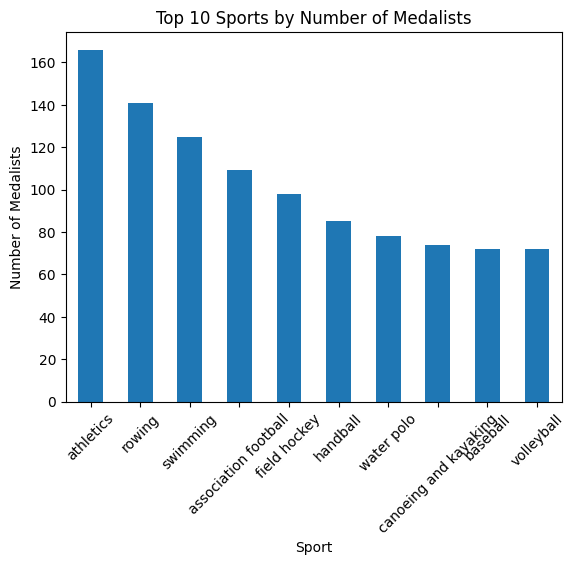

In [63]:
# Count the top 10 sports by number of medalists
top_sports = tidy_df["sport"].value_counts().head(10)

# Create a bar chart
top_sports.plot(kind="bar")
plt.title("Top 10 Sports by Number of Medalists")
plt.xlabel("Sport")
plt.ylabel("Number of Medalists")
plt.xticks(rotation=45)
plt.show()

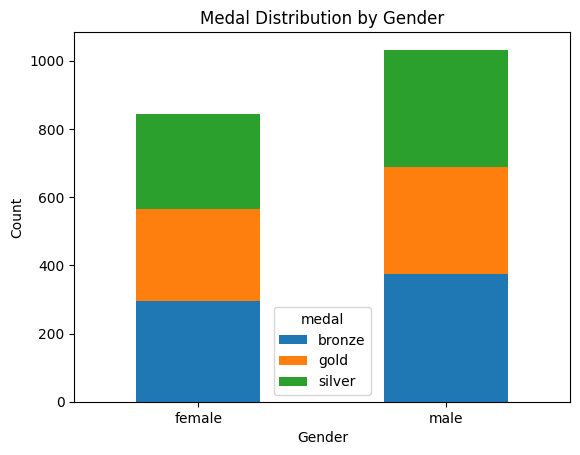

In [64]:
# Plot medal distribution by gender
gender_medals.plot(kind="bar", stacked=True)
plt.title("Medal Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 8. 

# This project demonstrates how tidy data principles can transform complex datasets into structured formats suitable for analysis.  

# By using pandas tools such as "melt()", "str.split()", and aggregation functions, the dataset becomes easier to interpret and visualize.  

# Tidy data improves analytical efficiency and is a foundational concept in modern data science workflows.

In [65]:
tidy_df.to_csv("olympics_08_medalists_tidy.csv", index=False)